In [ ]:
import sys
sys.path.append("/content")

from adaline import Adaline

The dataset contains multiple input features, making direct visualization difficult in the original feature space. To address this, Principal Component Analysis (PCA) was applied to reduce the dimensionality of the dataset to two principal components while preserving as much variance as possible.

The dataset was first standardized and then projected onto the two largest eigenvectors of the covariance matrix. The resulting two-dimensional representation was plotted using a scatter plot.

In the visualization:

X-axis: Principal Component 1 (PC1)

Y-axis: Principal Component 2 (PC2)

Color scale: Represents the mess duration values

This projection provides a simplified view of the dataset structure and helps observe the distribution of samples in reduced dimensional space.

The PCA visualization helps understand the overall data distribution before training the model.

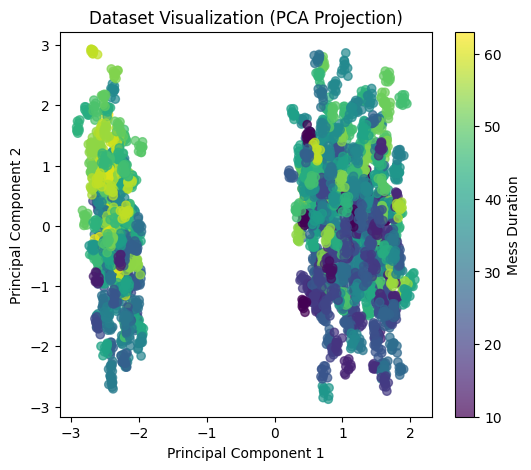

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Load dataset
df = pd.read_csv("/content/iit_h_mess_dataset_5000.csv")

# Features and target
X = df.drop(["student_id","mess_duration"], axis=1).values
y = df["mess_duration"].values

# Standardize
X = (X - X.mean(axis=0)) / X.std(axis=0)

# ----- PCA -----
X_centered = X - np.mean(X, axis=0)
cov_matrix = (X_centered.T @ X_centered) / X_centered.shape[0]

eig_vals, eig_vecs = np.linalg.eig(cov_matrix)

order = np.argsort(eig_vals)[::-1]
eig_vecs = eig_vecs[:, order]

W = eig_vecs[:, :2]

X_pca = X_centered @ W

# Plot dataset
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="viridis", alpha=0.7)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Dataset Visualization (PCA Projection)")
plt.colorbar(label="Mess Duration")

plt.show()

In [ ]:
np.random.seed(42)

indices = np.random.permutation(len(X))
split = int(0.8 * len(X))

train_idx = indices[:split]
val_idx = indices[split:]

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

(c) Learning Rate Experiment

To analyze the effect of the learning rate on model convergence, the ADALINE model was trained with different learning rates:

𝜂
∈
{
0.01
,
0.1
,
1.0
,
10.0
}
η∈{0.01,0.1,1.0,10.0}

For each learning rate, the model was trained for 100 epochs and the Mean Squared Error (MSE) was recorded at each epoch.

Separate convergence plots were generated showing MSE vs Epoch.

Observations

η = 0.01
The model converges slowly but steadily. The error decreases gradually over epochs, indicating stable but slow learning.

η = 0.1
The model converges faster and remains stable. This learning rate provides a good balance between speed and stability.

η = 1.0
The model learns quickly but shows oscillations in the error curve due to large weight updates.

η = 10.0
The learning rate is too large, causing unstable updates and divergence of the training process

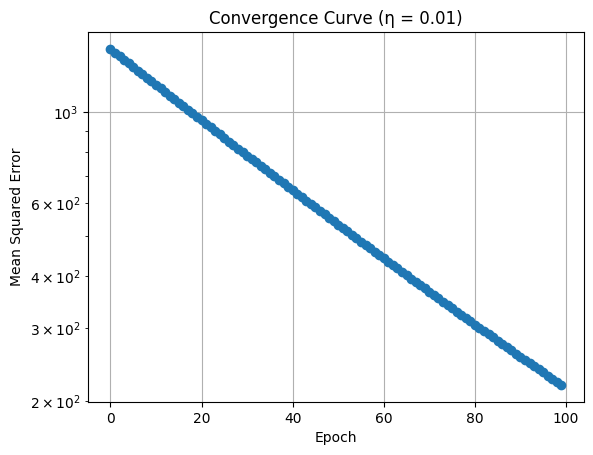

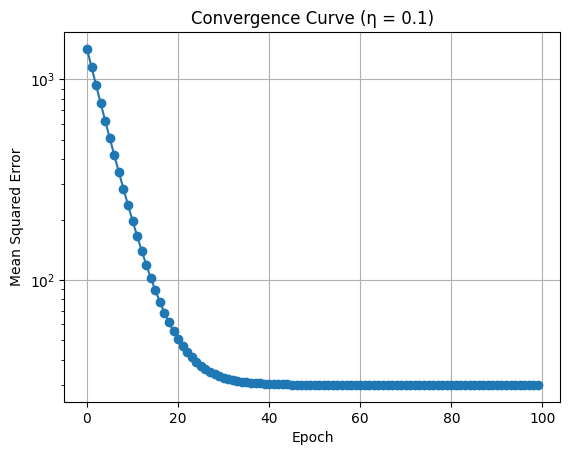

Training stopped due to divergence.


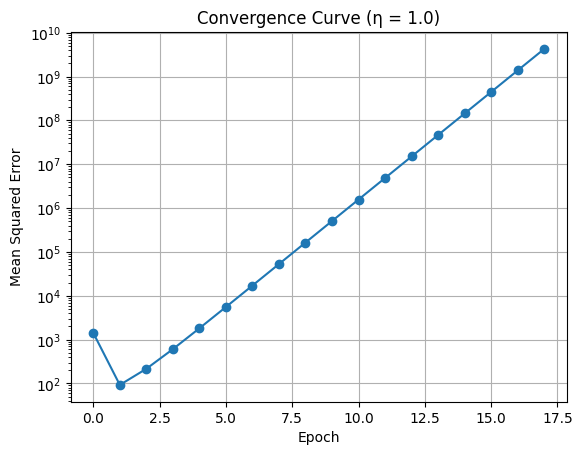

Training stopped due to divergence.


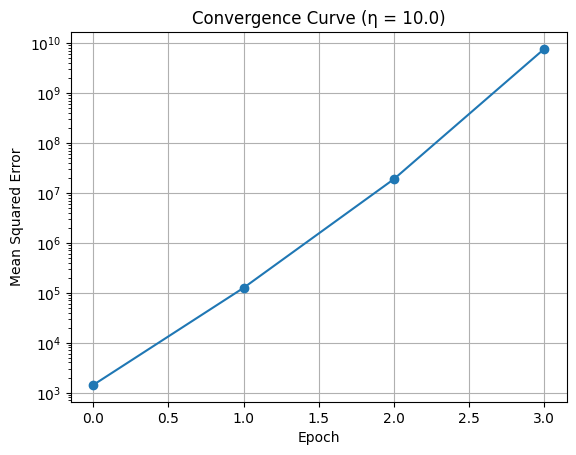

In [ ]:
etas = [0.01, 0.1, 1.0, 10.0]

for eta in etas:

    model = Adaline(lr=eta, epochs=100)

    train_hist, _ = model.fit(X_train, y_train, X_val, y_val)

    plt.figure()

    plt.plot(train_hist, marker='o')

    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Mean Squared Error")
    plt.title(f"Convergence Curve (η = {eta})")

    plt.grid(True)

    plt.show()

To study the effect of training data size on model performance, the training dataset size was varied from 10% to 100% in increments of 10%.

For each training size:

A subset of the training data was selected.

The ADALINE model was trained using the subset.

The model performance was evaluated on the validation dataset using Mean Squared Error (MSE).

The final validation error was plotted against the percentage of training data used.

Observations

The results show that as the training dataset size increases, the validation error gradually decreases. When only a small portion of the dataset is used for training, the model does not have enough information to learn the underlying patterns, resulting in higher prediction error.

As more training data becomes available, the model learns better representations of the data, improving generalization and reducing validation error.

Conclusion

This experiment demonstrates the importance of having sufficient training data. Increasing the training set size improves the model’s performance and reduces the prediction error on unseen data.

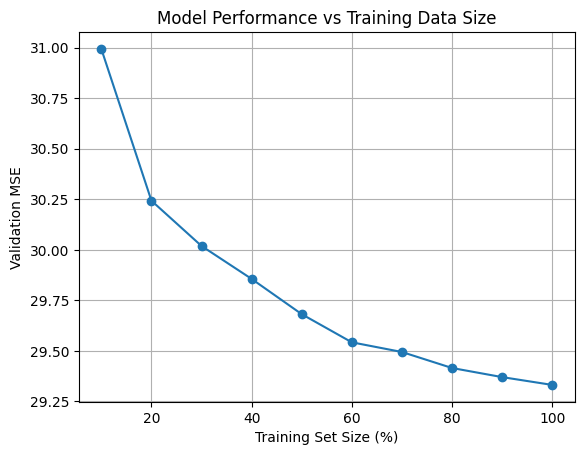

In [ ]:
sizes = np.arange(0.1, 1.1, 0.1)
mses = []

np.random.seed(42)

for size in sizes:

    subset_size = int(size * len(X_train))

    X_small = X_train[:subset_size]
    y_small = y_train[:subset_size]

    model = Adaline(lr=0.1, epochs=100)

    model.fit(X_small, y_small)

    mse = model.score(X_val, y_val)

    mses.append(mse)

plt.figure()

plt.plot(sizes * 100, mses, marker='o')

plt.xlabel("Training Set Size (%)")
plt.ylabel("Validation MSE")
plt.title("Model Performance vs Training Data Size")

plt.grid(True)

plt.show()

PCA helps visualize high-dimensional datasets by projecting them into a lower-dimensional space.

The learning rate significantly affects convergence speed and stability.

Larger training datasets improve model performance and reduce validation error.